# Simon's Algorithm — Demo

Walks through `algorithms.simon` end to end: build the oracle for a hidden
period, visualize the circuit and its measurement histogram, verify the
"every measured y satisfies y.s=0" property, and recover the hidden period
via `find_hidden_period()`.

See [../math.md](../math.md) for the theory and [../paper.md](../paper.md)
for the circuit derivation this notebook exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.simon import visualization
from algorithms.simon.circuit import build_simon_circuit
from algorithms.simon.execution import AerExecutor
from algorithms.simon.implementation import find_hidden_period
from algorithms.simon.oracles import LinearOracle, PermutationOracle

s = "101"
oracle = LinearOracle(s)
executor = AerExecutor()
print(f"Hidden period: {s}")

Hidden period: 101


## The circuit

`H^n -> oracle -> H^n -> measure input register`. The output register is
never measured — its entanglement with the input register is the
mechanism, not something to read out.

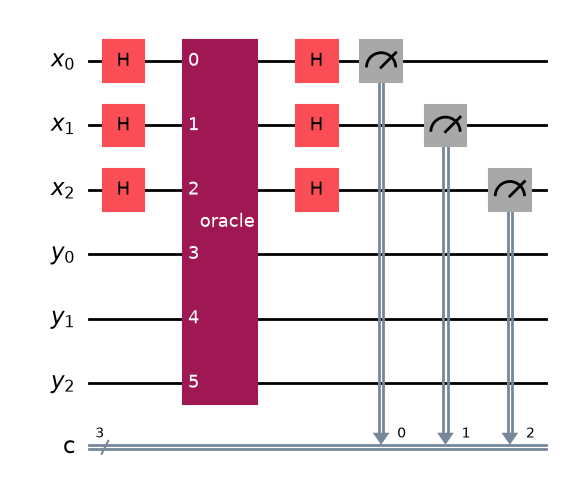

In [3]:
circuit = build_simon_circuit(len(s), oracle)
visualization.circuit_figure(circuit)

## Running it

Unlike Deutsch-Jozsa/Bernstein-Vazirani's single deterministic outcome, here
every run gives a *different*, uniformly random `y` — but every single one
satisfies `y . s = 0 mod 2` (see math.md). That's the histogram's story:
several distinct outcomes, all consistent with the same hidden `s`.

{'000': 56, '101': 50, '010': 44, '111': 50}
  y=000  y.s mod 2 = 0
  y=101  y.s mod 2 = 0
  y=010  y.s mod 2 = 0
  y=111  y.s mod 2 = 0


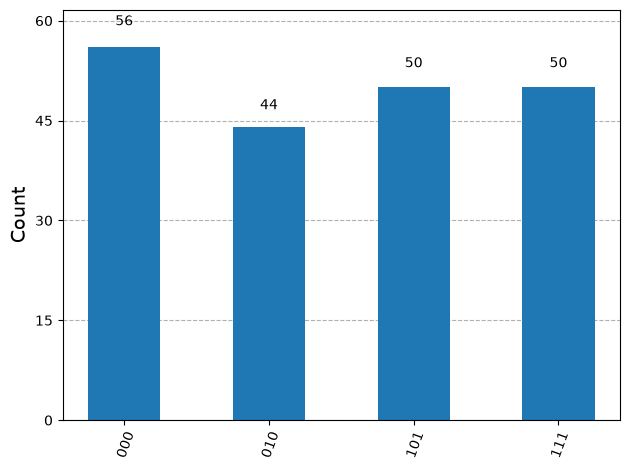

In [4]:
counts = executor.run(circuit, shots=200)
print(counts)
for y_str in counts:
    y = int(y_str, 2)
    dot = bin(y & int(s, 2)).count("1") % 2
    print(f"  y={y_str}  y.s mod 2 = {dot}")
visualization.plot_measurement_histogram(counts)

## `find_hidden_period`

Collects independent equations across multiple circuit runs, then solves
for `s` via from-scratch GF(2) Gaussian elimination — this repo's first
algorithm needing genuine classical linear algebra, not just a bitstring
read or a continued fraction.

In [5]:
result = find_hidden_period(len(s), oracle)
print(f"find_hidden_period recovered: {result!r} (expected {s!r})")
assert result == s

find_hidden_period recovered: '101' (expected '101')


## `PermutationOracle`: a genuinely non-linear two-to-one function

Same hidden period `s`, but the label assigned to each pair is scrambled
non-linearly (bit-reversal of its sort-index) — demonstrating the `Oracle`
abstraction isn't limited to linear functions like `LinearOracle`.

In [6]:
perm_oracle = PermutationOracle(s)
print("PermutationOracle labels:", perm_oracle.labels)
perm_result = find_hidden_period(len(s), perm_oracle)
print(f"find_hidden_period recovered: {perm_result!r} (expected {s!r})")
assert perm_result == s

PermutationOracle labels: [0, 2, 1, 3, 2, 0, 3, 1]


find_hidden_period recovered: '101' (expected '101')
